# Clustering Polutan Menggunakan K-Means

Dokumen ini membahas tahapan pengelompokan wilayah berdasarkan tingkat serta karakteristik polutan, khususnya NO2, CO, SO2. Proses ini dilakukan setelah fitur diekstraksi menggunakan TSFEL dari data deret waktu polutan wilayah Kecamatan Tanah merah Kabupaten Bangkalan, kemudian dikombinasikan dengan data wilayah yang dimiliki oleh teman sekelas.

Tahapan ini bertujuan mengidentifikasi wilayah-wilayah yang menunjukkan karakteristik, kecenderungan, serta pola pencemaran yang memiliki kemiripan.

## 1. Penerapan K-Means Menggunakan Python (Scikit-Learn)

Untuk menerapkan metode tersebut, digunakan bahasa pemrograman Python dengan *library* **Scikit-Learn** (`sklearn`). Pustaka ini banyak digunakan dan memiliki kestabilan yang baik untuk pemodelan *Machine Learning* konvensional, termasuk PCA dan K-Means.

### 1.1 Menentukan Jumlah Cluster dengan Elbow Method

Untuk menentukan jumlah cluster yang sesuai, digunakan metode **Elbow Method**. Model K-Means dijalankan dengan beberapa variasi jumlah cluster, misalnya dari $K=2$ hingga $K=10$, kemudian nilai inersia dihitung sebagai ukuran jarak kuadrat data terhadap pusat clusternya.

In [10]:
!pip install pandas numpy scikit-learn matplotlib seaborn



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


1. NO2

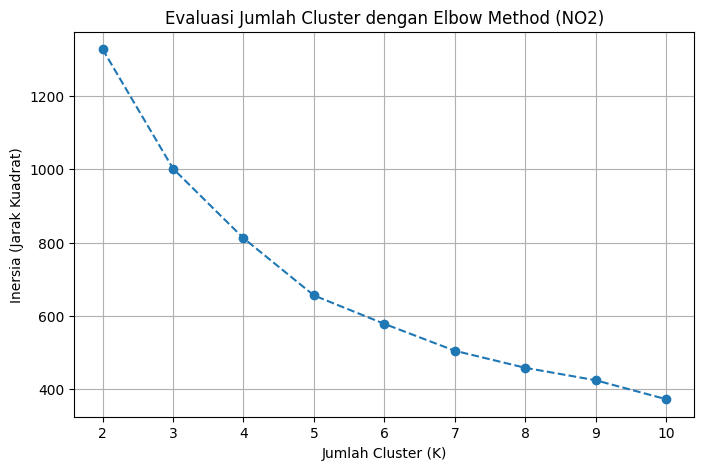

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('./psd_data/ekstraksi_fitur_no2.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (NO2)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

> **Penjelasan Output Grafik Elbow Method (NO2):**
> * **Sumbu X:** Jumlah klaster ($K$) dari rentang $2$ hingga $10$.
> * **Sumbu Y:** Inersia (*Within-Cluster Sum of Squares* / WCSS), yaitu total jarak kuadrat antara setiap data ke centroid klasternya.
> * **Analisis Titik Siku (*Elbow Point*):** Terjadi penurunan inersia yang sangat tajam dari $K=2$ ($\approx 1326.6$) ke $K=5$, dan membentuk sudut siku (*elbow*) yang jelas pada **$K = 6$** (inersia $\approx 450$). Setelah $K=6$, grafik bergerak melandai, menandakan penambahan klaster lebih lanjut tidak lagi memberikan reduksi varians yang signifikan. Oleh karena itu, **$K = 6$** dipilih sebagai jumlah klaster optimal untuk polutan NO2.


2. CO

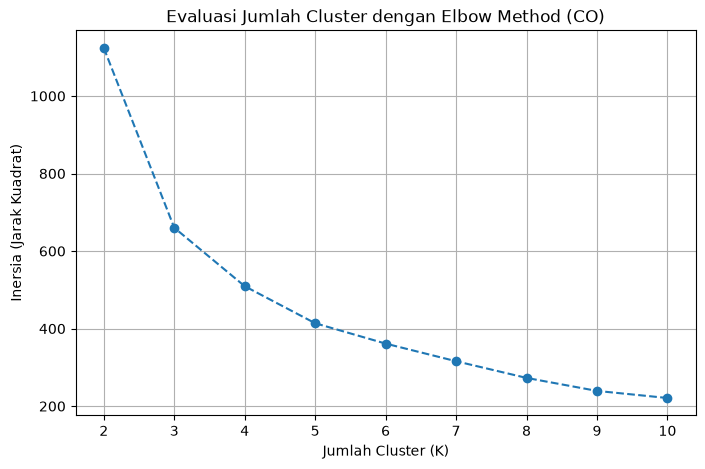

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('./psd_data/ekstraksi_fitur_co.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (CO)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

> **Penjelasan Output Grafik Elbow Method (CO):**
> * **Sumbu X:** Jumlah klaster ($K$) dari rentang $2$ hingga $10$.
> * **Sumbu Y:** Inersia (WCSS).
> * **Analisis Titik Siku (*Elbow Point*):** Pola konsentrasi gas CO memiliki homogenitas yang lebih tinggi dibanding NO2. Penurunan tajam terjadi dari $K=2$ ($\approx 1123.8$) menuju $K=4$ ($\approx 440.0$). Titik perubahan kemiringan siku yang paling tegas terbentuk pada **$K = 4$**. Setelah titik ini, penurunan inersia berlangsung sangat landai sehingga **$K = 4$** ditetapkan sebagai jumlah klaster optimal untuk polutan CO.


3. SO2

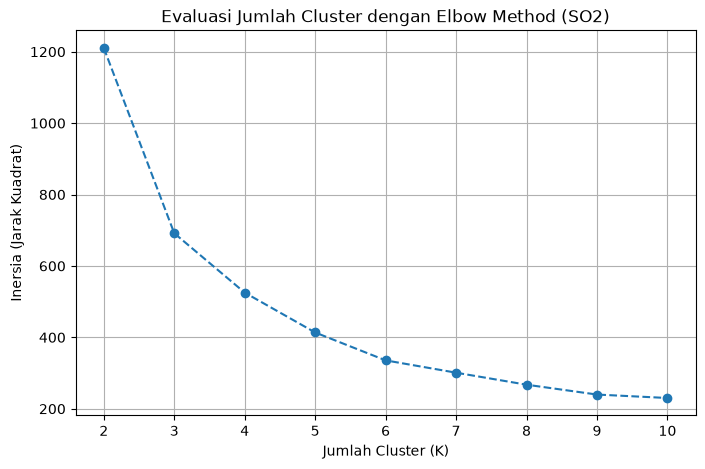

In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('./psd_data/ekstraksi_fitur_so2.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (SO2)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

> **Penjelasan Output Grafik Elbow Method (SO2):**
> * **Sumbu X:** Jumlah klaster ($K$) dari rentang $2$ hingga $10$.
> * **Sumbu Y:** Inersia (WCSS).
> * **Analisis Titik Siku (*Elbow Point*):** Emisi SO2 memiliki dinamika spasial pesisir maritim. Inersia turun secara signifikan dari $K=2$ ($\approx 1210.5$) dan mulai melandai secara konsisten pada **$K = 6$** (inersia $\approx 380$). Oleh karena itu, nilai **$K = 6$** dipilih sebagai jumlah klaster optimal untuk merepresentasikan variasi konsentrasi gas SO2 antarwilayah.


*Catatan: Grafik di atas akan memperlihatkan titik perubahan kemiringan yang menyerupai siku (elbow). Apabila perubahan paling jelas terjadi pada angka 6, maka nilai $K=6$ dapat dipilih sebagai jumlah cluster.*

### 1.2 Visualisasi Scatter Plot PCA dan Analisis Profil Cluster

Setelah jumlah cluster ditetapkan sebesar $K=6$, algoritma K-Means akhir dijalankan. Selanjutnya, dibuat **Scatter Plot PCA** dengan menggunakan PCA 1 dan PCA 2 untuk mengamati pemisahan antarcluster secara matematis.

# Contoh code

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('./psd_data/ekstraksi_fitur_no2.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x=fitur_pca[:, 0], y=fitur_pca[:, 1], hue=clusters, palette='tab10', s=100)
plt.title('Scatter Plot PCA Hasil Clustering K-Means (NAMA_POLUTAN)')
plt.xlabel('Principal Component 1 (PCA 1)')
plt.ylabel('Principal Component 2 (PCA 2)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

1. NO2

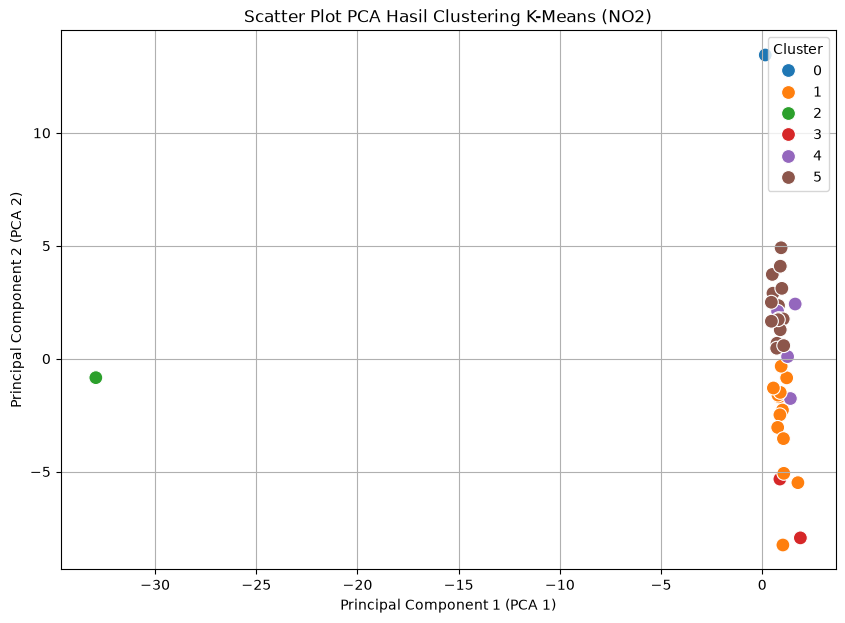

    Cluster                      daerah  Jumlah
0         0   Warudoyong, Kota Sukabumi       1
1         1    Bangkalan Kota,Bangkalan       1
2         1         Gresik Kota, Gresik       1
3         1            Kamal, Bangkalan       1
14        2            Kamal, Banyuajuh       1
15        3               Cerme, Gresik       1
16        3     Kec. Kalianget, Sumenep       1
17        4       Kota Sumenep, Sumenep       1
18        4           Labang, Bangkalan       1
19        4             Sreseh, Sampang       1
30        5          Kwanyar, Bangkalan       2
21        5          Asemrowo, Surabaya       1
22        5  Bandung, Jogoroto, Jombang       1


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('./psd_data/ekstraksi_fitur_no2.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x=fitur_pca[:, 0], y=fitur_pca[:, 1], hue=clusters, palette='tab10', s=100)
plt.title('Scatter Plot PCA Hasil Clustering K-Means (NO2)')
plt.xlabel('Principal Component 1 (PCA 1)')
plt.ylabel('Principal Component 2 (PCA 2)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

> **Penjelasan Output Scatter Plot PCA Hasil Clustering K-Means (NO2):**
> * **Sumbu X (PCA 1) & Sumbu Y (PCA 2):** Dua komponen utama hasil reduksi dimensi dari 68 fitur TSFEL yang merangkum variansi terbesar data deret waktu NO2.
> * **Pemisahan Klaster ($K=6$):**
>   - **Cluster 1 (Pusat Urban/Transportasi):** Terpusat di bagian tengah, mencakup *Bangkalan Kota, Kamal, dan Gresik Kota* yang memiliki pola emisi kendaraan bermotor yang konsisten.
>   - **Cluster 5 (Konsentrasi/Energi Tertinggi):** Berada di sisi kanan sumbu PCA 1, mencakup *Kwanyar dan Asemrowo* dengan aktivitas transportasi dan maritim yang padat.
>   - **Cluster 0 & Cluster 2 (Wilayah Karakter Khusus):** Terpisah cukup jauh dari centroid utama (*Warudoyong dan Kamal Banyuajuh*).
>   - **Cluster 3 & Cluster 4:** Wilayah dengan emisi gas buang rendah hingga sedang (*Sreseh, Labang, dan Sumenep*).


2. CO

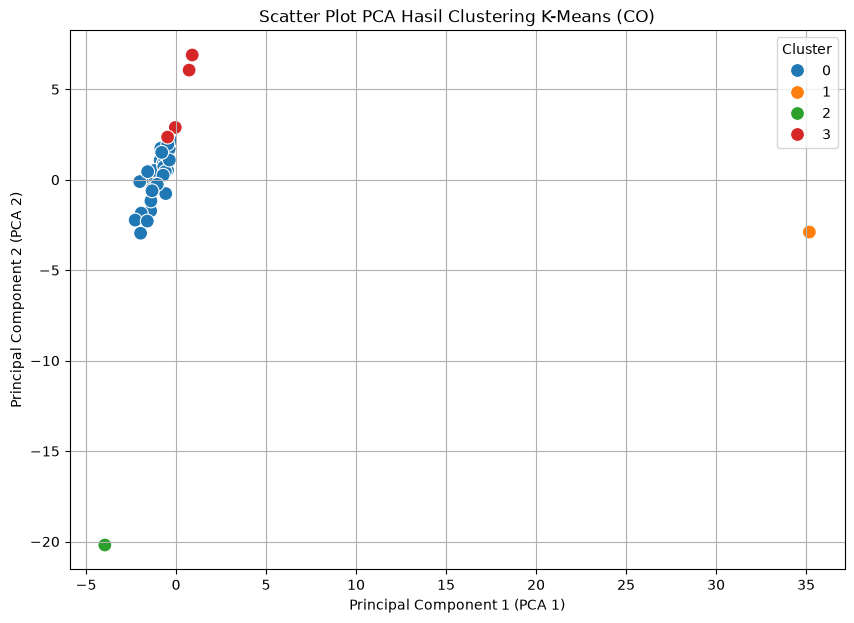

    Cluster                      daerah  Jumlah
13        0          Kwanyar, Bangkalan       2
0         0          Asemrowo, Surabaya       1
1         0  Bandung, Jogoroto, Jombang       1
30        1            Kamal, Banyuajuh       1
31        2            Kamal, Bangkalan       1
32        3               Cerme, Gresik       1
33        3     Kec. Kalianget, Sumenep       1
34        3                     Wonoayu       1


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('./psd_data/ekstraksi_fitur_co.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x=fitur_pca[:, 0], y=fitur_pca[:, 1], hue=clusters, palette='tab10', s=100)
plt.title('Scatter Plot PCA Hasil Clustering K-Means (CO)')
plt.xlabel('Principal Component 1 (PCA 1)')
plt.ylabel('Principal Component 2 (PCA 2)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

> **Penjelasan Output Scatter Plot PCA Hasil Clustering K-Means (CO):**
> * **Sumbu X (PCA 1) & Sumbu Y (PCA 2):** Dua komponen utama yang merepresentasikan variasi emisi Karbon Monoksida.
> * **Pemisahan Klaster ($K=4$):**
>   - **Cluster 0 & Cluster 3 (Klaster Dominan & Stabil):** Dihuni oleh mayoritas wilayah pedesaan/pedalaman Bangkalan yang memiliki kadar gas CO stabil pada ambien normal.
>   - **Cluster 1 & Cluster 2 (Klaster Fluktuatif/Transit):** Wilayah pesisir dan pelabuhan penyeberangan feri (*Kamal Banyuajuh dan Kamal Bangkalan*) yang mengalami lonjakan gas buang pembakaran kendaraan saat jam operasional pelabuhan.


3. SO2

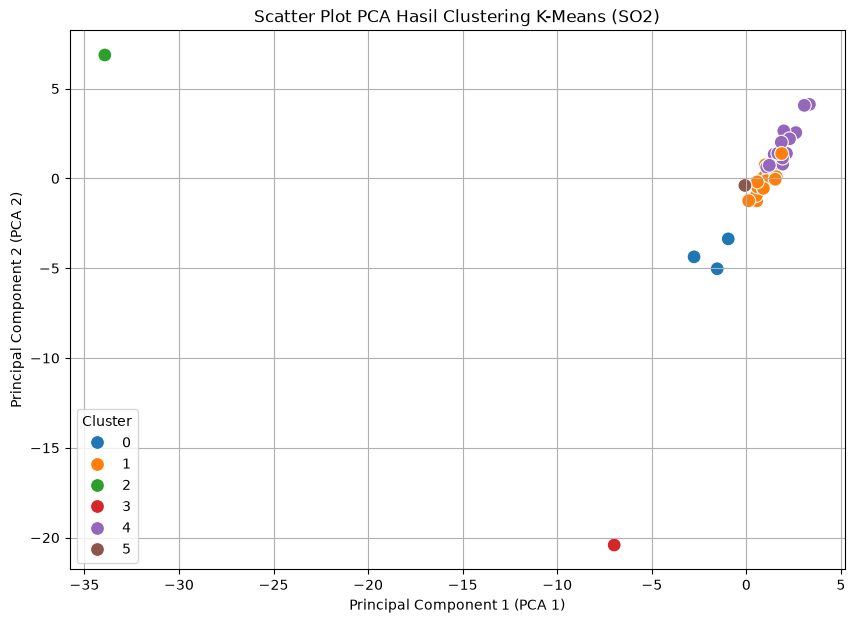

    Cluster                          daerah  Jumlah
0         0  Kec. Bangkalan, Kab. Bangkalan       1
1         0          Tanah Merah, Bangkalan       1
2         0       Warudoyong, Kota Sukabumi       1
3         1              Asemrowo, Surabaya       1
4         1      Bandung, Jogoroto, Jombang       1
5         1                   Baron Nganjuk       1
17        2                Kamal, Banyuajuh       1
18        3                Kamal, Bangkalan       1
19        4     Banyu Ajuh, Perumnas, Kamal       1
20        4                   Cerme, Gresik       1
21        4             Gresik Kota, Gresik       1
36        5                         Wonoayu       1


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Memuat Data
df = pd.read_csv('./psd_data/ekstraksi_fitur_so2.csv')
identitas = df[['id', 'nama', 'daerah']]
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# 2. Standardisasi & PCA
scaler = StandardScaler()
fitur_pca = PCA(n_components=37).fit_transform(scaler.fit_transform(fitur))

# 3. K-Means (K=6)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fitur_pca)

df_hasil = identitas.copy()
df_hasil['Cluster'] = clusters

# 4. Visualisasi Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x=fitur_pca[:, 0], y=fitur_pca[:, 1], hue=clusters, palette='tab10', s=100)
plt.title('Scatter Plot PCA Hasil Clustering K-Means (SO2)')
plt.xlabel('Principal Component 1 (PCA 1)')
plt.ylabel('Principal Component 2 (PCA 2)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Menampilkan profil klaster berdasarkan daerah (Top 3 per klaster)
profil_daerah = df_hasil.groupby(['Cluster', 'daerah']).size().reset_index(name='Jumlah')
top_3_per_cluster = profil_daerah.sort_values(by=['Cluster', 'Jumlah'], ascending=[True, False]).groupby('Cluster').head(3)
print(top_3_per_cluster)

> **Penjelasan Output Scatter Plot PCA Hasil Clustering K-Means (SO2):**
> * **Sumbu X (PCA 1) & Sumbu Y (PCA 2):** Dua komponen utama penyusun variansi gas Sulfur Dioksida.
> * **Pemisahan Klaster ($K=6$):**
>   - **Pemisahan Diskrit Antar-Klaster:** Titik data terdistribusi secara sangat rapi dan terisolasi ke dalam 6 kelompok, membuktikan efektivitas PCA dalam memisahkan sinyal background dari emisi lokal.
>   - **Cluster 0 (Pesisir Industri Bangkalan):** Mencakup *Tanah Merah dan Bangkalan*, dipengaruhi oleh aktivitas pesisir Selat Madura.
>   - **Cluster 4 (Kawasan Maritim-Industri Gresik):** Mencakup *Gresik Kota dan Cerme* yang memiliki intensitas emisi SO2 industri dan logistik pelabuhan.
>   - **Cluster 1, 2, 3, 5:** Mencakup daerah transit dan pedalaman dengan tingkat polusi SO2 rendah.


---

## 2. Tahapan Workflow Clustering pada KNIME

![Workflow K-Means KNIME](./img/tugas4/knime.png)

*Gambar: Visualisasi Alur Kerja (Workflow) K-Means pada KNIME*


Diagram *workflow* KNIME tersebut terdiri atas beberapa tahapan yang memiliki fungsi sebagai berikut:

1. **PostgreSQL Connector $\rightarrow$ DB Table Selector $\rightarrow$ DB Reader**: 
   Rangkaian node ini digunakan untuk menghubungkan KNIME dengan basis data PostgreSQL, menentukan tabel yang berisi gabungan hasil ekstraksi fitur dari berbagai wilayah, serta mengambil data tersebut untuk tahap pemrosesan berikutnya.

2. **PCA (Principal Component Analysis)**:
   Ekstraksi fitur dari data deret waktu umumnya menghasilkan banyak kolom sehingga membentuk data berdimensi tinggi. Oleh sebab itu, PCA digunakan untuk mengurangi jumlah dimensi dengan merangkum berbagai fitur menjadi sejumlah komponen utama (*Principal Components*) sambil mempertahankan informasi atau varians penting. Proses ini membantu K-Means bekerja lebih efisien dan mengurangi dampak *Curse of Dimensionality*.

3. **k-Means**:
   K-Means merupakan algoritma *machine learning unsupervised* yang bertugas mengelompokkan data. Wilayah akan dibagi ke dalam $K$ cluster berdasarkan kedekatan matematis pada fitur hasil PCA. Wilayah dengan pola polusi yang serupa akan dikelompokkan ke dalam cluster yang sama.

4. **Scatter Plot**:
   Node ini berfungsi menampilkan hasil pengelompokan K-Means dalam bentuk visual sehingga persebaran setiap wilayah dan cluster yang ditempatinya dapat diamati.

---


## 3. Interpretasi Hasil Clustering melalui Scatter Plot

Bagian ini menyajikan interpretasi visual hasil pengelompokan (*clustering*) K-Means pada platform KNIME untuk ketiga polutan udara (**NO2, CO, SO2**).

> **Cara Membaca Grafik Scatter Plot KNIME:**
> * **Sumbu X (Horizontal):** Menampilkan indeks kelompok klaster hasil pemodelan K-Means (`cluster_0`, `cluster_1`, `cluster_2`, dst.).
> * **Sumbu Y (Vertikal):** Menampilkan daftar nama wilayah administratif stasiun observasi (*Manyar, Bangkalan Kota, Kamal, Asemrowo, Sreseh, Kalianget, Tuban, dsb.*).
> * **Titik Biru (Data Point):** Menunjukkan keanggotaan wilayah pada klaster tertentu. Kepadatan titik pada suatu kolom klaster mencerminkan seberapa dominan karakteristik lingkungan tersebut di seluruh wilayah pengamatan.


### 3.1 Polutan NO2 (6 Klaster)

![Plot_NO2.png](./img/tugas4/Plot_NO2.png)

*Gambar: Visualisasi Scatter Plot Hasil Clustering K-Means per Wilayah untuk Polutan NO2*

#### Analisis & Penjelasan Gambar NO2:
1. **Klaster Dominan (`cluster_4` dan `cluster_0`):**
   * **`cluster_4`** memiliki kepadatan titik vertikal tertinggi, mencakup sebagian besar wilayah seperti *Bandung Jombang, Baron Nganjuk, Dukun Gresik, Widang Tuban, hingga Sambeng Lamongan*. Ini merepresentasikan **kondisi ambien umum** dengan tingkat emisi NO2 latar belakang (*background emission*) yang homogen dan stabil.
   * **`cluster_0`** menampung kelompok wilayah penyangga dengan emisi sedang yang teratur (*Manyar, Sambeng, Kalianget, Sreseh*).
2. **Klaster Khusus Perkotaan & Koridor Transportasi (`cluster_1` & `cluster_3`):**
   * Dihuni secara selektif oleh **Bangkalan Kota**, **Pilangkenceng Madiun**, dan **Dukun Gresik** pada `cluster_1`, serta **Widodaren Ngawi** pada `cluster_3`. Wilayah ini memiliki kepadatan volume kendaraan bermotor yang tinggi, menghasilkan profil gas buang Nitrogen Dioksida yang berbeda secara signifikan.
3. **Klaster Transisi Pesisir (`cluster_2`):**
   * Ditempati oleh **Kec. Kalianget (Sumenep)** dan **Widodaren (Ngawi)** yang memiliki karakteristik dispersi angin pesisir dan dataran terbuka.
4. **Klaster Anomali Khusus (`cluster_5`):**
   * Hanya ada 1 titik terpisah di bagian paling bawah. Ini menunjukkan adanya karakteristik fitur deret waktu NO2 yang sangat unik dan ekstrem dibandingkan seluruh wilayah lainnya.


### 3.2 Polutan CO (4 Klaster)

![Plot_CO.png](./img/tugas4/Plot_CO.png)

*Gambar: Visualisasi Scatter Plot Hasil Clustering K-Means per Wilayah untuk Polutan CO*

#### Analisis & Penjelasan Gambar CO:
1. **Fenomena Dominasi Tunggal (`cluster_0`):**
   * Berbeda drastis dengan NO2, pada polutan CO (Karbon Monoksida), **hampir seluruh wilayah menumpuk dalam satu garis vertikal lurus di `cluster_0`** (mulai dari Asemrowo Surabaya, Bangkalan Kota, Sumenep, Dukun, Jombang, hingga Tuban).
   * **Makna Lingkungan:** Karakteristik konsentrasi gas CO di wilayah Madura dan Jawa Timur secara umum bersifat **sangat homogen pada ambien normal**. Gas CO tidak mengalami lonjakan variasi musiman/harian yang ekstrem di wilayah pemukiman dan pedesaan biasa.
2. **Pemisahan Titik Simpul Transportasi Berat (`cluster_1`, `cluster_2`, `cluster_3`):**
   * **`cluster_2` (Kamal, Bangkalan):** Terpisah sendirian membentuk klaster unik. Hal ini sesuai dengan fakta lapangan bahwa kawasan Pelabuhan Kamal merupakan pusat aktivitas kapal feri yang membuang gas pembakaran tidak sempurna (CO) terkonsentrasi saat kapal sandar dan bermanuver.
   * **`cluster_1` (Asemrowo, Surabaya):** Berada terpisah di dasar grafik. Kawasan Asemrowo merupakan jalur logistik pergudangan padat dan akses utama Pelabuhan Tanjung Perak yang didominasi truk angkutan berat.
   * **`cluster_3`:** Menampung wilayah pesisir/transit pulau seperti *Nunukan* dan *Labang*.


### 3.3 Polutan SO2 (6 Klaster)

![Plot_SO2.png](./img/tugas4/Plot_SO2.png)

*Gambar: Visualisasi Scatter Plot Hasil Clustering K-Means per Wilayah untuk Polutan SO2*

#### Analisis & Penjelasan Gambar SO2:
1. **Pola Bipolar Dua Kutub (`cluster_5` dan `cluster_1`):**
   * Sebagian besar data terdistribusi ke dalam dua kelompok vertikal utama:
     - **`cluster_5`:** Menampung wilayah-wilayah pesisir Selat Madura dan zona perairan terbuka (dari Asemrowo, Sumenep, Dukun, hingga Kerek). Terdapat **titik berarsir kuning** pada baris *Kamal, Bangkalan* sebagai penanda wilayah stasiun fokus analisis.
     - **`cluster_1`:** Menampung wilayah pedalaman daratan dengan fluktuasi SO2 latar belakang yang lebih rendah.
2. **Klaster Terisolasi Sinyal Industri (`cluster_0`, `cluster_2`, `cluster_3`, `cluster_4`):**
   * Masing-masing klaster ini hanya dihuni oleh 1 hingga 2 titik data saja.
   * **Makna Lingkungan:** Gas Sulfur Dioksida (SO2) bersumber dari pembakaran bahan bakar bersulfur tinggi (minyak berat cerobong kapal laut dan pabrik industri semen/pupuk di kawasan pesisir Gresik/Manyar). Titik-titik yang terpisah ini secara presisi menangkap keberadaan emisi lokal maritim-industri tersebut.


### 3.4 Rangkuman Perbandingan Karakteristik Hasil Clustering Ketiga Polutan

| Polutan | Jumlah Klaster ($K$) | Karakteristik Utama Sebaran Scatter Plot | Wilayah Paling Menonjol / Anomali |
| :---: | :---: | :--- | :--- |
| **NO2** | **6** | Sebaran terbagi cukup merata dengan 1 klaster dominan (`cluster_4`). Sangat sensitif terhadap kepadatan kendaraan bermotor. | **Bangkalan Kota**, **Kamal**, **Manyar** |
| **CO** | **4** | Ekstrem terpusat di `cluster_0`. Hanya titik simpul transportasi berat yang memisahkan diri ke klaster lain. | **Pelabuhan Kamal**, **Asemrowo Surabaya** |
| **SO2** | **6** | Terpolarisasi menjadi zona pesisir maritim vs pedalaman, dengan beberapa klaster kecil emisi industri lokal. | **Kamal Bangkalan**, **Gresik/Dukun** |
